<a href="https://colab.research.google.com/github/tsiamba/Projet_GPI_Tsiambaka/blob/main/Projet_GPI_structurale_Tsiambaka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

import urllib.request
import io
from mpl_toolkits.mplot3d import Axes3D


# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
%pip install mrcfile
%pip install biopython
import mrcfile
from Bio.PDB import PDBParser, PDBIO
#%pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
#%pip install scikit-image

# Set random seed for reproducibility
np.random.seed(42)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.9 MB/s eta 0:00:00


Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=6f5a5dff-ea93-4453-8fbe-b5021970991a
To: /content/map.mrc
100%|██████████| 228M/228M [00:02<00:00, 78.3MB/s]



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: single 2D image


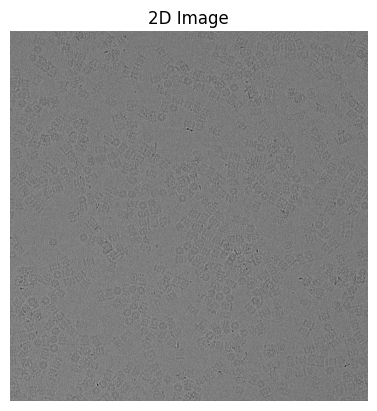

In [6]:
## image preparation

file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: single 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")


(1919, 1855)


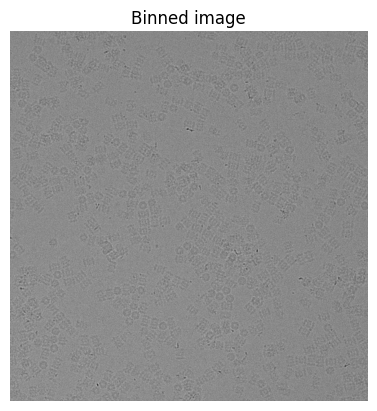

8
22


In [7]:
###binning

def bin_image(image, bin_size):
    """
    Performs binning (spatial downsampling) on an image.

    Args:
        image: Input image as numpy array
        bin_size: Size of the bin (e.g., 2 for 2x2 binning)

    Returns:
        Binned image with reduced resolution
    """
    h, w = image.shape
    # Calculate new dimensions
    new_h = h // bin_size
    new_w = w // bin_size

    # Reshape and compute mean of each bin
    binned = image[:new_h*bin_size, :new_w*bin_size].reshape(new_h, bin_size, new_w, bin_size)
    binned = binned.mean(axis=(1, 3)).astype(np.uint8)

    return binned

binned_image = bin_image(data, 4)
print(binned_image.shape)
plt.imshow(binned_image, cmap='gray')
plt.title("Binned image")
plt.axis('off')
plt.show()

print(binned_image.min())
print(binned_image.max())



0.0
1.0


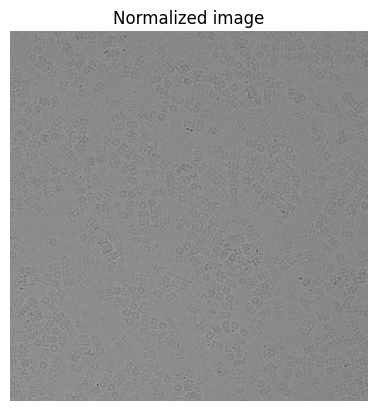

In [8]:
#normalization
def normalization(image):
  image = image.astype(np.float32)

  image = (image - image.min()) / (image.max() - image.min())
  return image

normalized_image = normalization(binned_image)
print(normalized_image.min())
print(normalized_image.max())
plt.imshow(normalized_image, cmap='gray')
plt.title("Normalized image")
plt.axis('off')
plt.show()

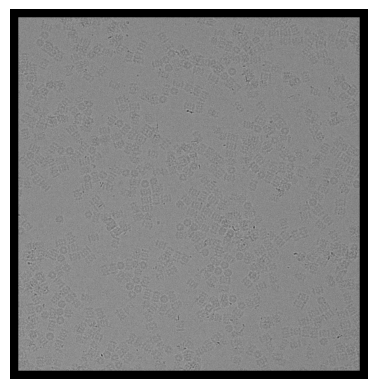

In [12]:
# Function to apply different padding modes
def apply_padding(img, pad_width, mode='constant', constant_value=255):
    """
    Apply padding to an image using NumPy.

    Parameters:
    -----------
    img : ndarray
        Input image
    pad_width : int or tuple
        Number of pixels to pad on each side
    mode : str
        Padding mode: 'constant', 'edge', 'reflect', 'wrap'
    constant_value : int
        Value used for constant padding

    Returns:
    --------
    padded : ndarray
        Padded image
    """
    if isinstance(pad_width, int):
        pad_width = ((pad_width, pad_width), (pad_width, pad_width))

    if mode == 'constant':
        padded = np.pad(img, pad_width, mode='constant', constant_values=constant_value)
    else:
        padded = np.pad(img, pad_width, mode=mode)

    return padded

pad_width = 45

padded_img = apply_padding(normalized_image, pad_width, mode='constant', constant_value=0)

plt.imshow(padded_img, cmap='gray')
plt.axis('off')
plt.show()

PART 7: PDB FILES - PROTEIN STRUCTURES & 2D PROJECTIONS

📚 WHAT IS A PDB FILE?

PDB (Protein Data Bank) Format:
  - Standard text format for storing 3D atomic structures
  - Contains coordinates of atoms in proteins, DNA, RNA, small molecules
  - Publicly available at: https://www.rcsb.org/

PDB File Structure:
  - HEADER: Basic information about the structure
  - TITLE: Name/description of the molecule
  - ATOM records: X, Y, Z coordinates of each atom
  - HETATM: Heterogeneous atoms (ligands, water, ions)
  - CONECT: Connectivity information between atoms
  - END: Marks end of file

Each structure has a 4-character PDB ID (e.g., 6BDF)
  - First 3 characters: Unique identifier
  - Last character: Chain ID

Applications:
  - Drug discovery and molecular docking
  - Protein structure validation
  - Creating 2D projections (electron microscopy simulation)
  - Computational biology research


📥 FETCHING PDB STRUCTURE: 6BDF
✓ Successfully downloaded 3885327 bytes
✓ Saved to 6BDF.pdb

🔬 STR

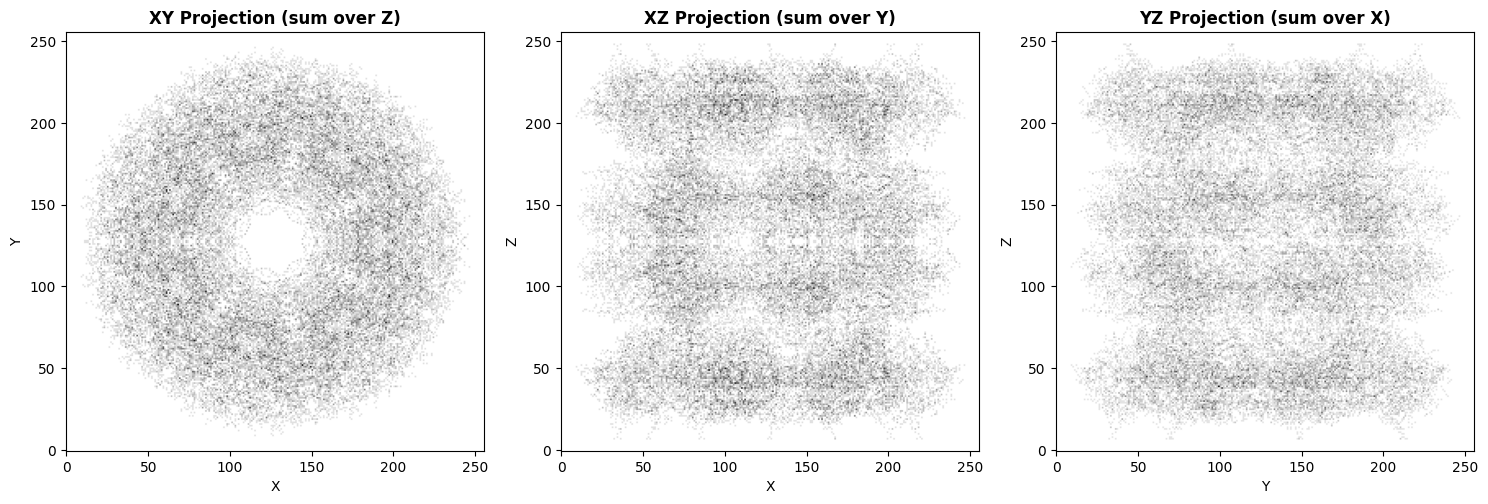


Summed Density Projections:
  - Pixel intensity = number of atoms projected into that pixel
  - Brighter = higher density
  - Approximates ideal projection images (no noise, no CTF)


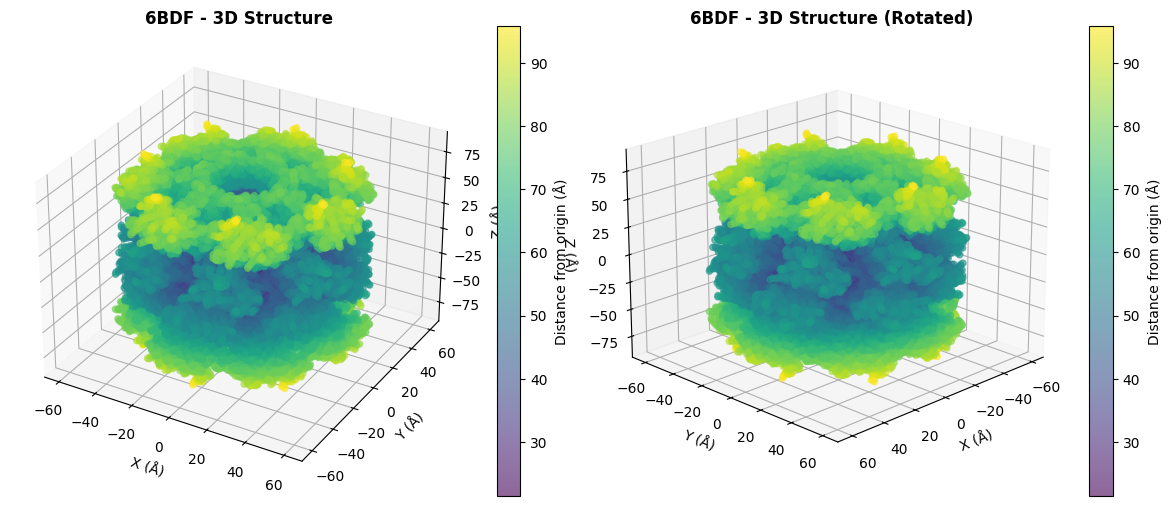

In [13]:
##template
print("="*70)
print("PART 7: PDB FILES - PROTEIN STRUCTURES & 2D PROJECTIONS")
print("="*70)

print("\n" + "="*70)
print("📚 WHAT IS A PDB FILE?")
print("="*70)
print("""
PDB (Protein Data Bank) Format:
  - Standard text format for storing 3D atomic structures
  - Contains coordinates of atoms in proteins, DNA, RNA, small molecules
  - Publicly available at: https://www.rcsb.org/

PDB File Structure:
  - HEADER: Basic information about the structure
  - TITLE: Name/description of the molecule
  - ATOM records: X, Y, Z coordinates of each atom
  - HETATM: Heterogeneous atoms (ligands, water, ions)
  - CONECT: Connectivity information between atoms
  - END: Marks end of file

Each structure has a 4-character PDB ID (e.g., 6BDF)
  - First 3 characters: Unique identifier
  - Last character: Chain ID

Applications:
  - Drug discovery and molecular docking
  - Protein structure validation
  - Creating 2D projections (electron microscopy simulation)
  - Computational biology research
""")

print("\n" + "="*70)
print("📥 FETCHING PDB STRUCTURE: 6BDF")
print("="*70)

pdb_id = "6BDF"
pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

try:
    print(f"Downloading {pdb_id} from RCSB PDB...")
    with urllib.request.urlopen(pdb_url, timeout=10) as response:
        pdb_content = response.read().decode('utf-8')
    print(f"✓ Successfully downloaded {len(pdb_content)} bytes")

    # Save to file
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, 'w') as f:
        f.write(pdb_content)
    print(f"✓ Saved to {pdb_file}")

    # Parse the PDB file
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)

    print("\n" + "="*70)
    print("🔬 STRUCTURE INFORMATION")
    print("="*70)

    # Extract information
    model = structure[0]
    chains = list(model.get_chains())

    print(f"\nStructure ID: {pdb_id}")
    print(f"Number of models: {len(structure)}")
    print(f"Number of chains: {len(chains)}")

    for chain in chains:
        residues = list(chain.get_residues())
        atoms = list(chain.get_atoms())
        print(f"\nChain {chain.id}:")
        print(f"  - Residues: {len(residues)}")
        print(f"  - Atoms: {len(atoms)}")

    print("\n" + "="*70)
    print("📋 PDB FILE FORMAT - ATOM RECORD EXPLANATION")
    print("="*70)
    print("""
Each ATOM line contains 12 fixed-width columns:

ATOM      1  N   ALA A   1      20.154  29.699   5.276  1.00 20.00           N
├─────┬────┬───┬──┬──┬──┬────────────────────┬──┬────┬────────┘
│     │    │   │  │  │  │  X, Y, Z           │  │B  │Element
│     │    │   │  │  │  │  Coordinates (Å)   │  │   │
│     │    │   │  │  │  │                    │Occ│   │
Column│    │   │  │  │  └─ Atomic positions  │   │   │
      │    │   │  │  │
   1-6│    │   │  │  └─ Residue #
      │    │   │  │
   7-11│  Name  │  └─ Chain ID (A, B, C...)
      │         │
      └─ Atom # └─ Residue type (ALA=Alanine, GLY=Glycine, etc.)

Key Columns:
  - 1-6: ATOM/HETATM record type
  - 7-11: Atom serial number
  - 13-16: Atom name (CA=Alpha carbon, CB=Beta carbon, N=Backbone N, etc.)
  - 18-20: Residue name (3-letter code)
  - 22: Chain identifier
  - 23-26: Residue sequence number
  - 31-38: X coordinate (Ångströms)
  - 39-46: Y coordinate
  - 47-54: Z coordinate
  - 55-60: Occupancy (1.0 = full occupancy, <1.0 = partial)
  - 61-66: Temperature factor/B-factor (protein flexibility)
  - 77-78: Element symbol
""")

    # Extract atomic coordinates
    print("\n" + "="*70)
    print("🧬 ATOMIC COORDINATES FROM 6BDF")
    print("="*70)

    all_atoms = []
    for chain in model.get_chains():
        for residue in chain.get_residues():
            for atom in residue.get_atoms():
                coord = atom.get_coord()
                all_atoms.append({
                    'name': atom.name,
                    'residue': residue.resname,
                    'residue_id': residue.id[1],
                    'x': coord[0],
                    'y': coord[1],
                    'z': coord[2],
                    'b_factor': atom.bfactor
                })

    print(f"Total atoms: {len(all_atoms)}")
    print(f"\nFirst 10 atoms:")
    print(f"{'Atom':6} {'Residue':8} {'Res#':5} {'X (Å)':10} {'Y (Å)':10} {'Z (Å)':10} {'B-factor':10}")
    print("-" * 60)
    for atom in all_atoms[:10]:
        print(f"{atom['name']:6} {atom['residue']:8} {atom['residue_id']:5d} {atom['x']:10.3f} {atom['y']:10.3f} {atom['z']:10.3f} {atom['b_factor']:10.2f}")

    # Extract coordinates for visualization
    coords = np.array([[atom['x'], atom['y'], atom['z']] for atom in all_atoms])

    print(f"\nCoordinate statistics:")
    print(f"  X range: [{coords[:, 0].min():.3f}, {coords[:, 0].max():.3f}] Å")
    print(f"  Y range: [{coords[:, 1].min():.3f}, {coords[:, 1].max():.3f}] Å")
    print(f"  Z range: [{coords[:, 2].min():.3f}, {coords[:, 2].max():.3f}] Å")

    print("\n" + "="*70)
    print("🎯 CREATING DENSITY-BASED 2D PROJECTIONS (SUMMED GRAYSCALE)")
    print("="*70)

    # Center coordinates
    coords_centered = coords - coords.mean(axis=0)

    # Resolution of projection image
    img_size = 256  # pixels
    padding = 5     # Å padding around structure

    # Function to create summed projection
    def create_projection(coord1, coord2, bins=256):
        # Determine bounds
        min1, max1 = coord1.min() - padding, coord1.max() + padding
        min2, max2 = coord2.min() - padding, coord2.max() + padding

        # 2D histogram (counts = density)
        H, xedges, yedges = np.histogram2d(coord1, coord2, bins=bins,
                                        range=[[min1, max1], [min2, max2]])

        # Normalize for display
        H = H / H.max()
        H = 1 - H
        return H

    # Create projections
    proj_xy = create_projection(coords_centered[:, 0], coords_centered[:, 1], img_size)
    proj_xz = create_projection(coords_centered[:, 0], coords_centered[:, 2], img_size)
    proj_yz = create_projection(coords_centered[:, 1], coords_centered[:, 2], img_size)

    # Plot projections
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # XY projection
    axes[0].imshow(proj_xy.T, cmap='gray', origin='lower')
    axes[0].set_title('XY Projection (sum over Z)', fontweight='bold')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')

    # XZ projection
    axes[1].imshow(proj_xz.T, cmap='gray', origin='lower')
    axes[1].set_title('XZ Projection (sum over Y)', fontweight='bold')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')

    # YZ projection
    axes[2].imshow(proj_yz.T, cmap='gray', origin='lower')
    axes[2].set_title('YZ Projection (sum over X)', fontweight='bold')
    axes[2].set_xlabel('Y')
    axes[2].set_ylabel('Z')

    plt.tight_layout()
    plt.show()

    print("\nSummed Density Projections:")
    print("  - Pixel intensity = number of atoms projected into that pixel")
    print("  - Brighter = higher density")
    print("  - Approximates ideal projection images (no noise, no CTF)")

    # 3D visualization
    fig = plt.figure(figsize=(12, 5))

    # 3D scatter plot
    ax4 = fig.add_subplot(1, 2, 1, projection='3d')
    scatter = ax4.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                          c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax4.set_xlabel('X (Å)', fontsize=10)
    ax4.set_ylabel('Y (Å)', fontsize=10)
    ax4.set_zlabel('Z (Å)', fontsize=10)
    ax4.set_title(f'{pdb_id} - 3D Structure', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax4, label='Distance from origin (Å)')

    # 3D scatter plot - rotated view
    ax5 = fig.add_subplot(1, 2, 2, projection='3d')
    scatter2 = ax5.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                           c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax5.view_init(elev=20, azim=45)  # Different viewing angle
    ax5.set_xlabel('X (Å)', fontsize=10)
    ax5.set_ylabel('Y (Å)', fontsize=10)
    ax5.set_zlabel('Z (Å)', fontsize=10)
    ax5.set_title(f'{pdb_id} - 3D Structure (Rotated)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter2, ax=ax5, label='Distance from origin (Å)')

    plt.tight_layout()
    plt.show()


except urllib.error.URLError as e:
    print(f"❌ Error downloading PDB file: {e}")
    print("   Make sure you have internet connection")
except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {e}")